# Check digestion output for ispfprm specific peptides 
In this notebook we will use the results from the tryptic in silico digestion and check for how many isoforms we can find a unique peptide right after the digestion.

# Setup
## Import and install Packages

In [ ]:
import sys
import os
import session_info

In [ ]:
import pandas as pd

In [ ]:
# Display session information
session_info.show()

## Set working directory

In [ ]:
cwd = os.getcwd()
if not cwd.endswith("Isoform_Database/Jupyter_environment/Isoform_Database_SIAF/02_In-Silico_Digestion"):
    print("WARNING: The working directory is not set to the '02_In-Silico_Digestion'!")
    print("Current working directory:", cwd)
else:
    print(f"Working directory is correctly set to the '02_In-Silico_Digestion' folder (\"{cwd}\").")

In [ ]:
# Data directories
mapping_dir = "../01_UniProt/data/mapping/"
digestion_output_dir = "data/digestion_output"

## Read in Dataframes

In [ ]:
iso_canonical_mapping = pd.read_csv(os.path.join(mapping_dir, 'iso_canonical_mapping.csv'))
iso_canonical_mapping_flat = pd.read_csv(os.path.join(mapping_dir, 'iso_canonical_mapping_flat.csv'))

digestion_full_proteome_filtered =  pd.read_csv(os.path.join(digestion_output_dir, 'digestion_full_proteome_filtered.csv'))

# Unique Isoform Peptide Fragments
Implementaton to flag isoforms for which we can't find a unique peptide like this.

Insertions/Alternative Exons: These almost always produce unique peptides.
Deletions: These create a new "junction" peptide (where two parts of the protein are joined that aren't joined in the canonical).
Truncations: These often produce no unique peptides because the isoform is just a shorter version of the original.

Implementation: The "Best Candidate" Selection
Instead of just filtering, we will rank peptides for every isoform. This ensures that if a unique peptide exists, you grab it; if not, you flag that isoform for a different enzyme.

In [ ]:
# Global Map -> group the WHOLE proteome by sequence
# If a peptide exists in an isoform AND its canonical parent, 
# the set will be {'ID-1', 'ID-canonical'} and len() will be > 1.
peptide_to_ids = digestion_full_proteome_filtered .groupby('seq')['ID'].apply(set).to_dict()

# 3. Define target isoforms (The ones we want to find markers for)
target_isoform_ids = iso_canonical_mapping_flat['Isoform_ID'].unique()

# 4. Pre-filter digestion for ONLY target isoforms to speed up the loop
isoform_data = digestion_full_proteome_filtered [digestion_full_proteome_filtered ['ID'].isin(target_isoform_ids)].groupby('ID')['seq'].apply(list).to_dict()

final_results = []

# 5. The Loop
for iso_id in target_isoform_ids:
    peptides = isoform_data.get(iso_id, [])
    unique_peptides = []
    
    for p in peptides:
        # Strict Uniqueness Check:
        # The peptide must belong to exactly one ID, and that ID must be iso_id.
        # If it belongs to iso_id AND a canonical ID, it fails this check.
        occurrence_set = peptide_to_ids.get(p, set())
        
        if occurrence_set == {iso_id}:
            unique_peptides.append(p)
            
    if unique_peptides:
        # Selection logic: Longest peptide is usually better for Mass Spec (higher specificity)
        best_peptide = max(unique_peptides, key=len)
        status = "Unique Marker Found"
    else:
        # Logic check: did we have peptides that just weren't unique?
        status = "Shared with Canonical/Other" if peptides else "No peptides in digestion"
        best_peptide = None
        
    final_results.append({
        "Isoform_ID": iso_id,
        "Unique_Peptide": best_peptide,
        "Status": status,
        "Peptide_Count": len(unique_peptides)
    })

results_df = pd.DataFrame(final_results)

In [ ]:
results_df

In [ ]:
results_df.to_csv('data/unique_isoform_peptides.csv', index = False)

In [ ]:
missing_from_digestion = results_df[results_df['Status'] == "ID not found in digestion"]['Isoform_ID'].tolist()

print(f"--- Summary Statistics ---")
print(results_df['Status'].value_counts())
print("-" * 30)

if missing_from_digestion:
    print(f" {len(missing_from_digestion)} IDs were NOT found in the digestion dataframe:")
    print(missing_from_digestion)
else:
    print("All target IDs were present in the digestion dataframe.")
    print("-" * 30)

# Filter for the specific status and convert the Isoform_ID column to a list
no_peptides_ids = results_df[results_df['Status'] == "No peptides in digestion"]['Isoform_ID'].tolist()

# Display the results
print("Proteins with no peptides in Digestion:")
print(no_peptides_ids)
print("-" * 30)

Now all target IDs are in the digestion df, before there wer 248 that were not present, but this was fixed in NB 1.4 (mapping).

IDs not matched in ID mapping from UniProt (50 proteins): Q14114-5
Q93009-2
Q13243-4
P30307-5
O00712-3
Q08493-4
O14628-2
O14628-3
Q9HBH9-3
Q08493-6
Q08493-5
P47756-3
Q96LB4-2
Q96JB1-4
Q9NPG1-2
Q8IWY9-3
Q08648-6
Q9BYG7-3
P40855-2
P40855-3
O15409-3
P26367-3
P42702-2
Q13621-2
P52272-3
Q9HBH9-4
O15534-3
Q9UL45-3
Q99259-2
Q9Y281-2
P52757-2
Q9HBH9-5
P10826-4
O15534-2
O00291-2
Q9HAT1-2
Q2M385-2
Q96JB1-3
P13497-7
Q9H0M0-4
Q8WVD5-2
P20963-2
Q9H0M0-5
P40855-4
P04150-4
Q13705-2
O15119-4
Q9BYG7-4
Q08493-7
Q8N7M0-2

For all of these IDs the seqeunce is not available on UniProt.

The other 98 IDs could be mapped but for 95 of these there are Isoforms with this info: The sequence of this isoform can be found in the external entry linked below. Isoforms of the same protein are often annotated in two different entries if their sequences differ significantly. The remaining three IDs showed up their 2nd isoforms were a duplicated sequence but the canonical ids not removed for the unique canonical sequences. The second Isoforms also had to be added to the no_duplicates fasta file (digestion input).

We found out that these are two individual uniprot entries that are linked and all isoforms of one protein are isoforms of the other protein in uniprot (both ways). So we seperated them and only kept the true isoforms. Like this we don't lose any seqeunce information and only map the immediate isoforms to their canonical sequence. I will keep the list in this notebook as to not lose it and remember where it came from but it was used to clean up the mapping in notebook 1.4 and will not be used in this notebook.

The following 5 proteins don't have any peptides after filtering: 'P21145-2', 'Q71RG4-4', 'Q8IZ96-16', 'Q8N6Y0-2', 'Q9BQY9-3'.

P21145-2

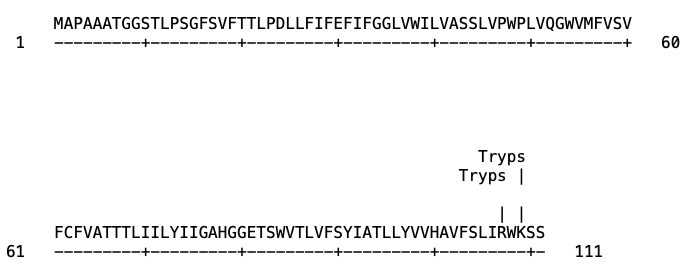

Q71RG4-4

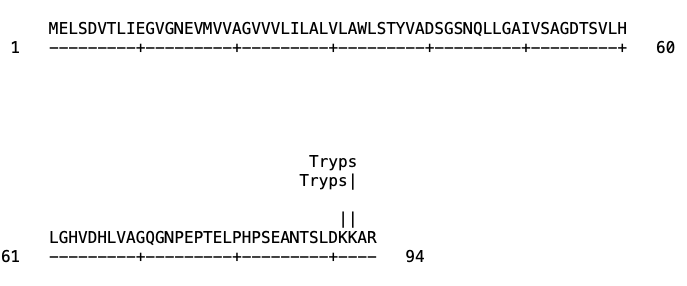

Q8IZ96-16

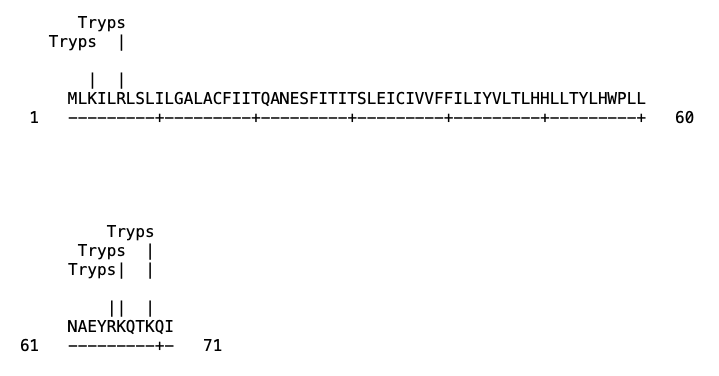

Q8N6Y0-2

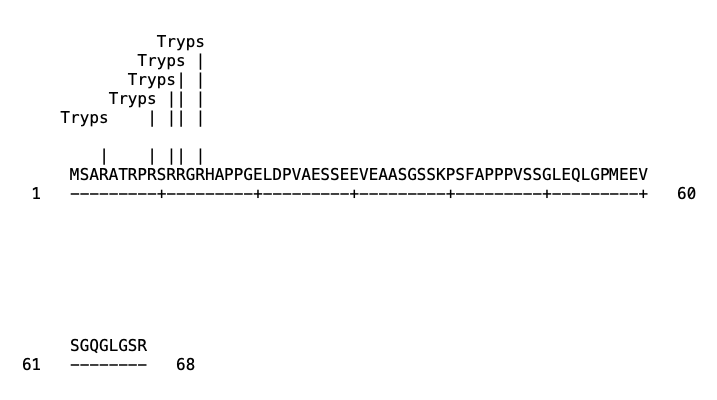

Q9BQY9-3

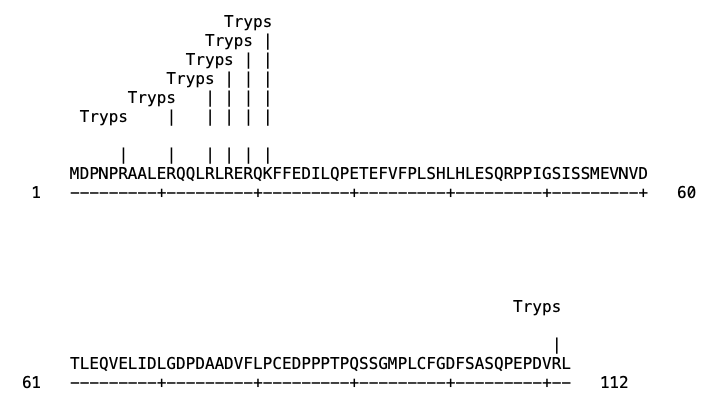